# AI 활용에 관하여

과제는 AI 를 사용할 것을 전제로 만들어지고 있습니다.
하지만, 학습의 효율성을 위해서 무분별한 AI 사용은 권장드리지 않고 있어요.

따라서, AI 를 피어리뷰어로서 생각하고 사용해주시는 것을 권고드립니다.  
이를 판단할 수 있는 하나의 기준으로는 같은 수업을 듣는 다른 친구에게 물어볼 수 있는 질문인가? 라고 스스로 물어보는 것도 좋은 기준이 될 수 있을 것 같습니다.

아래는 이에 대한 몇가지 예시입니다.


> AI 사용 가능:
> - 문법 및 API 확인
> - 오류 메시지 해석
> - 실행 환경 문제 해결
> - 내가 작성한 설명의 반례 요청

> AI에 맡기지 않을 것:
> - 실행 전 예측
> - 실행 결과에서 근거 선택
> - 의견 및 선택의 최종 판단

# 1주차 내용 복습하기

1주차에 어떤 내용을 학습했나 먼저 복습해봅시다.

**Q1. 머신러닝과 딥러닝은 어떻게 다른가요? 다음의 글을 참고하여 답변을 작성해주세요.**  
https://cloud.google.com/discover/deep-learning-vs-machine-learning?hl=ko

- 딥 러닝은 인공 신경망을 사용하여 정보를 처리하고 분석하는 머신러닝의 하위 집합이다. 인간 뇌의 활동에서 영감을 얻었으며, 비선형적인 상관관계를 만들 수 있지만 머신러닝보다 더 많은 데이터가 필요하다. 

- 반면, 머신러닝은 명시적으로 프로그래밍하지 않아도 시스템이 자율적으로 학습하고 개선할 수 있게 해주는 인공지능의 하위 집합을 의미한다. 머신러닝은 패턴을 인식하며, 새로운 데이터가 입력되면 예측을 수행한다.

**Q2. 머신러닝과 딥러닝은 어떤 관계를 가지고 있나요? 딥러닝이 아닌 머신러닝은 어떤 것이 있을까요?**  
**인공신경망(ANN) 은 어느 개념에 어떻게 적용되나요?**

- 딥러닝은 머신러닝의 하위 집합이다. 

- 딥러닝이 아닌 머신러닝으로는 선형회귀가 있다.

- 선형 회귀의 가중합 계산에 비정형성을 더하고, 그것을 뉴런으로 보아 쌓아 올린 것이 인공신경망이다.

**Q3. 다음의 뉴런(퍼셉트론) 이 하는 연산을 할 수 있도록 아래의 코드를 완성해주세요.**  
함수를 구현하고, 그 아래의 코드를 실행시켜 채점해보고 디버깅해보세요.

<img src="./imgs/perceptron.png" width=500>

In [6]:
import numpy as np

def relu(x):
    if(x > 0):
        return x
    else:
        return 0

def perceptron(x, w, b):
    """[x1, x2]를 입력, [w1, w2]를 가중치, b 를 편향으로 입력받아, z 를 출력합니다."""
    x=np.array(x)
    w=np.array(w)
    z=np.dot(x, w) + b
    return relu(z)

### 채점머신
위의 함수를 구현한 다음에 아래 코드를 다시 실행해주세요.  
다시 실행하면 채점결과가 나옵니다. 틀린 경우, 어떤 예제에서 틀렸는지 알려줍니다.  
**아래의 코드를 이해할 필요는 전혀!!!! 없습니다!**

In [7]:
# 올바른 함수인지 체크하는 부분입니다. 수정하시면 안됩니다! 지금은 이해하지 않아도 전혀 문제없습니다.
# 위의 함수를 구현하고, 이 셀을 실행하여 셀프채점해보세요. 틀린 예시에 대한 결과를 보여줍니다!

def check_relu():
    for v in [4, 0, -3, 3.4]:
        assert relu(v) == max(v, 0), f"{v} 에서 {max(v, 0)} 이 출력되어야하나, {relu(v)} 가 출력되었습니다."
    return

def check_perceptron():
    xs = np.array([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0], [-1.0, -2.0]])
    ws = np.array([[3.0, 4.3], [-1.0, -3.0], [-2.3, 2.1], [-3.2, 4.0]])
    bs = np.array([2.2, 1.2, -3.4, 5.0])

    for x, w, b in zip(xs, ws, bs):
        expected = max(w.T @ x + b, 0)
        actual = perceptron(x, w, b)

        assert abs(expected - actual) <= 1e-10, \
            f"x={x}, w={w}, b={b}에서 {expected}가 출력되어야하나, {actual}이 출력되었습니다."

try: 
    check_relu()
    check_perceptron()
    print("🎉 정답입니다!")
except AssertionError as e:
    print(e)

🎉 정답입니다!


풀고나서: 퍼셉트론의 입력과 출력은 **행렬곱** 으로 처리할 수 있습니다. `numpy.dot()` 혹은 동일한 연산인 `@` 에 대해 찾아보세요.

**Q4. 위 문제에서는 `ReLU` 를 구현해보았는데, 이번에는 softmax 와 sigmoid 를 구현해봅시다.**  
함수를 구현하고, 그 아래의 코드를 실행시켜 채점해보고 디버깅해보세요.  
HINT: `numpy` 에는 `exp()` 라는 $e^x$ 를 계산해주는 함수가 있습니다.

In [10]:
def softmax(xs):
    xs = np.array(xs)
    exp_x = np.exp(xs - np.max(xs))  # 안정적인 계산을 위해 최대값을 빼줍니다.
    return exp_x / np.sum(exp_x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

### 채점머신
위의 함수를 구현한 다음에 아래 코드를 다시 실행해주세요.  
다시 실행하면 채점결과가 나옵니다. 틀린 경우, 어떤 예제에서 틀렸는지 알려줍니다.  
**아래의 코드를 이해할 필요는 전혀!!!! 없습니다!**

In [11]:
# 올바른 함수인지 체크하는 부분입니다. 수정하시면 안됩니다!
# 위의 함수를 구현하고, 이 셀을 실행하여 셀프채점해보세요. 틀린 예시에 대한 결과를 보여줍니다!

import numpy as np

def check_softmax():
    xss = np.array([[1.0, 2.0, 3.0], [0.0, 0.0, 0.0], [-1.0, 1.0, 0.0], [4.0, -2.0, 0.5]])

    for xs in xss:
        expected = np.exp(xs) / np.sum(np.exp(xs))
        actual = softmax(xs)

        assert np.all(abs(expected - actual) <= 1e-10), \
            f"xs={xs}에서 {expected}가 출력되어야 하나, {actual}이 출력되었습니다."
    return

def check_sigmoid():
    xs = [4, 0, -3, 3.4]

    for x in xs:
        expected = 1 / (1 + np.exp(-x))
        actual = sigmoid(x)

        assert abs(expected - actual) <= 1e-10, \
            f"x={x}에서 {expected}가 출력되어야 하나, {actual}이 출력되었습니다."
    return

try:
    check_softmax()
    check_sigmoid()
    print("🎉 정답입니다!")
except AssertionError as e:
    print(e)

🎉 정답입니다!


# Fashion MNIST 실습하기

수업 시간에 배운 데이터셋과 문제를 바탕으로 직접 코드를 채워봅시다.

In [21]:
# 먼저 필요한 라이브러리를 가져옵니다.
# `as` 를 통해서 긴 이름에 대해 짧은 이름으로 사용할 수 있습니다.
# `from` 을 통해서 라이브러리의 일부만 가져올 수 있습니다. 

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt 
from tensorflow import keras # tensorflow 중 keras 관련 라이브러리를 불러옵니다

Matplotlib is building the font cache; this may take a moment.


In [22]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

먼저 데이터를 불러와봅시다.  
저희가 사용할 fashion mnist 는 유명한 문제라 keras 를 통해서 가져올 수 있습니다.  
`keras.datasets` 에서 `fashion_mnist` 를 불러올 수 있습니다.

**Q5. 아래의 `None` 위치에 들어갈 함수를 찾아주세요.**

보통은 데이터를 직접 다운로드하고 불러온 다음, train set / test set 으로 나누는 과정까지 진행해야합니다.  

In [23]:
(train_input, train_target), (test_input, test_target) \
    = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


데이터를 일부를 간단하게 출력하여 어떻게 생겼나 살펴봅시다.  
아래의 변수를 임의로 바꾸어 첫번째 이미지를 일부분 살펴봅시다.

In [67]:
row_start = 0
row_end = 28
col_start = 0
col_end = 28

**Q6. 각 start, end 는 어느 범위까지 가능한가요? 실행 전 확인해야할 조건은 무엇이 있을까요?**  
변수를 자유롭게 수정하고, 아래의 코드의 결과를 바탕으로 추론해봅시다. 혹은 추가로 코드를 작성하셔도 됩니다.

- 28x28 픽셀이므로, start, end는 0~28까지 가능하다.
- start < end 이어야 함

In [68]:
# 첫번째 데이터의 일부를 보여주는 코드

print(train_input[0, row_start:row_end, col_start:col_end])
print(type(train_input))

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

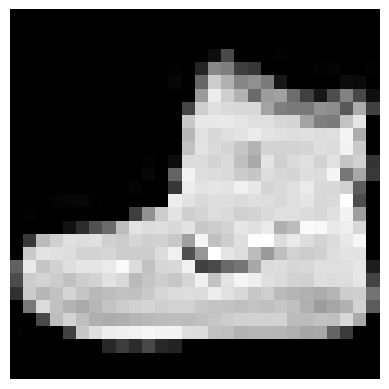

In [69]:
# 위의 배열을 그대로 Heat Map 으로 보여주는 코드
# Heat Map 은 해당 위치의 값이 높을수록 흰색을, 낮을수록 검은색을 띄워보여줍니다.

plt.imshow(train_input[0, row_start:row_end, col_start:col_end], cmap='gray')
plt.axis('off')
plt.show()

모델은 특정한 형태의 입력만을 받을 수 있습니다.  
이를 위해서는 데이터가 어떤 형태인지, 어떤 입력을 받을 수 있도록 모델을 구성하는지 반드시 고려해야 합니다.
그렇다면,

**Q7. 어떤 멤버(class member) 가 데이터의 형태를 가지고 있을까요?**  
이에 보여줄 수 있는 코드를 작성하고, 그 출력값이 어떤 의미인지 해석해주세요.  
크게 어떤 타입의 값을 가지고 있는지, 하나의 fashion_mnist 데이터가 어떻게 구성되어있는지 파악해주세요.

In [ ]:
# 여기에 print 함수를 활용하여, `train_input` 와 `train_target` 의 형태를 출력해주세요.
print("train_input shape:", train_input.shape)
print("train_target shape:", train_target.shape)


train_input shape: (60000, 28, 28)
train_target shape: (60000,)


- train_input shape: 60000개의 데이터, 28x28 픽셀, 즉 28x28의 차원 이미지가 60000층 쌓여있는 3차원 구조
- train_target shape: 60000개의 1차원 데이터

파악한 내용과 fashion mnist 데이터에 대한 설명을 참고하면,  
의류에 대한 이미지를 바탕으로 어떤 카테고리에 속하는 옷인지 맞춰야합니다.  

카테고리를 표현하는 방법은 다양하지만, 여기서는 각 카테고리에 일종의 id 를 부여하여, 0부터 9까지로 표현되고 있습니다.  
https://keras.io/api/datasets/fashion_mnist/

In [81]:
# np.unique 는 주어진 데이터에서 어떤 값들이 등장하는지 알려주며, return_counts 를 명시했기 때문에, 각 값이 몇번 등장하는지 알려줍니다.

print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


위의 출력을 통해 0부터 9까지 모두 균등하게 6000개씩 등장한다는 것을 알 수 있습니다.  
이 사실들을 바탕으로 본격적으로 인공신경망으로 문제를 해결해봅시다.

# 인공신경망

## 텐서플로와 케라스

In [82]:
import tensorflow as tf
from tensorflow import keras

인공신경망을 활용하기 위해, 저희는 `tensorflow` 와 `keras` 를 활용할 예정입니다.  
`tensorflow` 는 신경망과 관련된 직접적인 연산을 다루는 저수준 라이브러리이며, `keras` 는 이를 사람이 사용하기 쉽게 만들어둔 고수준 라이브러리입니다.

## 데이터 전처리

모델을 만들기 전에, 데이터 전처리를 진행합니다.  
데이터 전처리는 모델이 학습하기 쉬운 형태로 데이터를 변형시키는 것으로, 여기서는 정규화와 평탄화를 시행했습니다.

일반적으로, 학습에 실시한 전처리는 평가에서도 적용되어야 합니다.

In [83]:
train_scaled = train_input / 255.0 # 정규화
train_scaled = train_scaled.reshape(-1, 28*28) # 평탄화(flatten)

처음 데이터를 불러왔을 때 했던 말을 기억하시나요?  
fashion mnist 는 유명한 예제이기 때문에, 이미 keras 라이브러리 내부에 존재합니다.  
또한, 이미 train/test 로 분리를 해서 출력하는 것을 확인했습니다. 이를 그대로 활용하겠습니다.  

In [84]:
print(train_scaled.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(60000, 784) (60000,)
(10000, 28, 28) (10000,)


In [85]:
# test 데이터에도 같은 정규화를 진행해줍니다.

test_scaled = test_input / 255.0 # 정규화
test_scaled = test_scaled.reshape(-1, 28*28) # 평탄화(flatten)

In [86]:
print(test_scaled.shape, test_target.shape)

(10000, 784) (10000,)


## 인공신경망으로 모델 만들기

이번에는 간단하게 1개의 dense Layer 를 가진 모델을 구성해보겠습니다.

<img src=./imgs/mlp.jpg width=500 />

https://ocw.mit.edu/courses/6-7960-deep-learning-fall-2024/resources/mit6_7960_f24_lec1_pdf/  

Dense Layer 는 모든 입력이 모든 퍼셉트론에 연결된 구조를 의미합니다.  
예를 들어 4개의 입력이 들어오면서, 5개의 퍼셉트론으로 구성된 Layer 라고 했을 때, 총 20개의 연결이 형성되어 있습니다.

**Q8. 그렇다면 fashion-mnist 로 1개의 Dense Layer 를 가진 저희 모델은 몇개의 가중치와 편향을 가질까요?**  
(keras 에서는 model 을 구성하고, `summary` 함수를 사용하면 각 Layer 별로 사용하는 파라미터 개수를 알 수 있습니다.  
하지만 코드없이 구조만 보고 추론해봅시다.)

- 7,840개의 가중치, 10개의 편향

그렇다면, 실제 코드로 작성해보겠습니다.  
keras 는 각 Layer 를 별도로 구현한 다음, 순차적으로 Layer 를 붙이는 방식으로 모델을 구성할 수 있습니다.  

`keras.Input` : 모델에 입력될 데이터의 형태를 지정해줄 수 있습니다.  
`keras.Dense` : 앞에서 이야기한 Dense Layer 를 구현해줍니다. 퍼셉트론을 몇개로 설정할지, 어떤 활성화함수를 사용할지 지정할 수 있습니다.

**Q9. 우리의 모델에서 Dense Layer 의 출력값이 곧 모델 전체의 출력값입니다.**  
**그렇다면, 모델의 출력값이 10개의 카테고리에 대한 확률에 대응되어야할 때, Dense Layer 의 퍼셉트론 수는 몇개가 되어야할까요?**  
**아래의 `0` 자리에 직접 넣어 확인해주세요. 또한, ReLU 나 sigmoid 가 아닌 softmax 를 사용한 이유를 적어주세요.** 

- 0과 1사이의 값으로 반환하여, 확률값처럼 쓰이게 하기 위함

In [87]:
input_layer = keras.Input(shape = (784, ))
dense = keras.layers.Dense(10, activation='softmax') # 여기의 0 을 지우고 답을 입력해주세요.

In [88]:
model = keras.Sequential([
        input_layer,
        dense
])

아래 코드로 전체 가중치 개수를 실제로 확인할 수 있습니다.  
가중치와 편향의 개수를 합치면 정확히 같은 숫자가 나오게 됩니다.

In [89]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

## 인공신경망으로 패션 아이템 추론하기

In [90]:
# 학습 전에 모델의 설정을 조립합니다.

model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [91]:
# 주어진 설정과 입력된 학습 데이터를 바탕으로 학습을 진행합니다.  
# 학습에 대한 내용은 2주차에 자세하게 다루겠습니다.

model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 356us/step - accuracy: 0.8008 - loss: 0.5856
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 322us/step - accuracy: 0.8417 - loss: 0.4659
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 347us/step - accuracy: 0.8491 - loss: 0.4444
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 324us/step - accuracy: 0.8530 - loss: 0.4334
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 311us/step - accuracy: 0.8558 - loss: 0.4264


In [94]:
# test 데이터를 바탕으로 결과를 확인합니다
# accuracy 가 제 환경에서는 대략 0.83 으로 83% 정도의 정확도를 가집니다. 이 정확도는 사람마다 조금씩 다를 수 있습니다.

model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step - accuracy: 0.8331 - loss: 0.4870


E0000 00:00:1789657968.980523 4797988 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[0.4869943857192993, 0.8331000208854675]

## 다음 주차 스터디 예고

이번 주차에는 추론에 대해 다뤄보았습니다.  
추론을 진행하기 위해서 저희는 모델에 대해 `complie`, `fit` 을 한 다음에서야 test 데이터를 통해 추론해볼 수 있었습니다.  

이 때 `complie` 에서 사용된 `loss` 파라미터와 `fit` 이 어떤 역할을 하는지 미리 조사해보면, 다음주 스터디를 조금더 수월하게 들을 수 있을 듯합니다.

#### 심화 문제(필수 아님)

퍼셉트론을 이용하여 모든 입력을 연결하는 것이 앞에서 배웠던 Dense Layer 입니다.  
재밌는 점은 퍼셉트론과 ReLU 활성화함수만으로 모든 함수를 일정 오차 이내로 근사하는 것이 가능합니다.  

정말 간단하게 설명하면, 2개의 Layer 만으로 리만합을 설명할 때 사용하는 직사각형을 유도할 수 있습니다.  
이 직사각형을 사용하면 모든 부분에서 일정 이하의 오차로 근사하는 것이 가능합니다.  
더 궁금하다면 다음의 강의를 참고해주세요.  
https://www.youtube.com/watch?v=ySaoWrv3T_Q

이를 확인해보는 문제로 OR 게이트를 구현해볼 수 있습니다.  
아래의 조건을 만족하는 $w_1$, $w_2$, $w_3$, $w_4$, $b_1$, $b_2$ 를 구해보세요.

* 입력: $x_1$, $x_2$
* 출력: $y$
* layer1: [$w_1$, $w_2$] 가중치와 $b_1$ 편향
* layer2: [$w_3$, $w_4$] 가중치와 $b_2$ 편향

조건: $x_1 > 0$ OR $x_2 > 0$ 이라면, layer1, layer2 를 거친 모델의 출력값도 0보다 커야한다.  
(문제의 출처: https://ocw.mit.edu/courses/6-7960-deep-learning-fall-2024/resources/mit6_7960_f24_hw1_pdf/ 의 7.(a))